# U-Net Baseline — Anatomical Landmark Detection on Long-Leg Radiographs

**Purpose.** This notebook is the *baseline* for our work: a single U-Net that localises
12 surgical landmarks directly on full-size standing long-leg (hip-to-ankle) radiographs and,
from them, reconstructs the **Miniaci high-tibial-osteotomy (HTO) correction angle** for each
leg. It deliberately uses the simplest sound recipe — heatmap regression with a plain U-Net and
a per-channel MSE loss — so that later, more elaborate models can be measured against it on
identical data, folds, and metrics.

## What the model does
Each radiograph is letterboxed to 768×768 and passed once through a U-Net that emits **12
half-resolution Gaussian heatmaps**, one per landmark. Landmarks are decoded as the per-channel
arg-max and mapped back to native image coordinates. From the six landmarks of each leg the
notebook builds the Fujisawa point and the Miniaci construction to obtain the correction angle α,
then measures how closely the predicted angle agrees with the annotated one.

## Pipeline (top to bottom)
1. **Data** — COCO keypoint annotations → letterbox resize → 12-channel Gaussian heatmap targets,
   with training-only augmentation injected through the dataset's `augment_fn`.
2. **Model** — a from-scratch U-Net (`64 → 128 → 256 → 512 → 1024`) with a **linear head**: no
   final activation, so the raw heatmaps feed straight into the loss.
3. **Loss** — `masked_heatmap_loss`: per-channel MSE between predicted and target heatmaps,
   averaged over the **visible** landmarks only.
4. **Training** — AdamW + cosine schedule with gradient clipping; every epoch logs the heatmap
   loss, keypoint MSE (px²), and PCK at four thresholds, and saves the best-val-MSE checkpoint.
5. **Evaluation** — 5-fold cross-validation with the pooled correction-angle agreement battery
   (mean / median / SD / RMSE error, ICC(2,1), Pearson r, Bland–Altman limits, % within ±1.63°),
   then a fixed 80/10/10 split with a held-out test agreement and a combined summary table.

## Key design choices
- **Linear head + MSE** (no sigmoid) — the classic heatmap-regression formulation; arg-max
  localisation is invariant to the output scale.
- **Half-resolution heatmaps** (`HEATMAP_SCALE = 0.5`) to keep memory tractable at 768 px input.
- **Heatmap-only** — no differentiable angle term; the correction angle is a *post-hoc* geometric
  measurement, never a training signal.

## Code layout
The reusable pipeline lives in the local **`hto`** package (it must sit next to this notebook):

- `hto.data` — dataset construction + image preprocessing
- `hto.metrics` — masked heatmap loss, coordinate decode, MSE / PCK metrics
- `hto.geometry` — letterbox-inverse transform + Miniaci correction-angle geometry
- `hto.stats` — ICC agreement statistics

The **augmentation policy** and the **training / evaluation driver** stay in the notebook, so the
parts you are most likely to tune are in front of you.

## Requirements
A CUDA GPU is strongly recommended. Point `DATA_DIR` at the annotated HTO set
(`hto_annotations.json` plus the radiograph images); model checkpoints are written under
`kfolds_models/`.

## Imports & Configuration

Load the deep-learning stack and fix the global hyperparameters. The notebook is
fully self-contained: the U-Net and every helper — including the heatmap-to-coordinate
decoder — are defined inline, with no external model dependencies.

In [1]:
import os
import json
import random
import math
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn

from hto.data import GlobalRadiographKeypointDataset, preprocess_global_image
from hto.metrics import (
    masked_heatmap_loss,
    calculate_mse,
    calculate_pck,
    extract_coordinates,
)
from hto.geometry import map_global_to_orig, evaluate_side_geometry
from hto.stats import compute_icc

DATA_DIR       = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"

SEED           = 42
TARGET_SIZE    = 768
HEATMAP_SCALE  = 0.5
SIGMA          = 6.0
KP_EPOCHS      = 750
BATCH_SIZE     = 4
LEARNING_RATE  = 1e-4 * (HEATMAP_SCALE / 0.25)

# ── U-Net baseline configuration ────────────────────────────────────────
MODEL_VARIANT   = "unet"    # keeps the _model_map[MODEL_VARIANT] call-sites identical to CV/final cells
UNET_BASE_CH    = 64        # base width; channels double each stage (64→128→256→512→1024 bottleneck)
UNET_BILINEAR   = False     # False = learned ConvTranspose2d upsampling; True = bilinear upsample + conv
CHECKPOINT_DIR  = "kfolds_models"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "best_model_unet_global.pt")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware device registered: {device}")

GLOBAL_KEYPOINT_NAMES = [
    "femur_head_lh", "knee_inner_lh", "ost_point_lh",
    "knee_outer_lh", "ankle_inner_lh", "ankle_outer_lh",
    "femur_head_rh", "knee_inner_rh", "ost_point_rh",
    "knee_outer_rh", "ankle_inner_rh", "ankle_outer_rh",
]

LANDMARK_COLORS = {
    "femur_head_lh":      "darkgreen",  "knee_inner_lh":    "darkblue",
    "ost_point_lh":       "darkred",    "knee_outer_lh":    "darkviolet",
    "ankle_inner_lh":     "darkorange", "ankle_outer_lh":   "teal",
    "fujisawa_lh":        "gold",       "ankle_c_lh":       "navy",
    "target_at_ankle_lh": "magenta",
    "femur_head_rh":      "lightgreen", "knee_inner_rh":    "lightblue",
    "ost_point_rh":       "lightcoral", "knee_outer_rh":    "plum",
    "ankle_inner_rh":     "sandybrown", "ankle_outer_rh":   "paleturquoise",
    "fujisawa_rh":        "khaki",      "ankle_c_rh":       "slategray",
    "target_at_ankle_rh": "violet",
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

Hardware device registered: cuda


## GPU Availability Check

Validate hardware acceleration before committing to a long training run.

In [2]:
print(f"PyTorch version: {torch.__version__}")
gpu_available = torch.cuda.is_available()
print(f"GPU available: {gpu_available}")
if gpu_available:
    print(f"GPU device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1+cu121
GPU available: True
GPU device name: NVIDIA H100 80GB HBM3


## Dataset Architecture

The dataset lives in the **`hto.data`** subpackage of the local **`hto`** package (imported above) so it can be reused and
tested outside the notebook, while the **augmentation policy stays in the notebook** and is
injected into the dataset — so you can tweak it here without touching the package. Three stages:

1. **Preprocessing** (`hto.data.preprocess_global_image`) – letterbox-resize each radiograph to
   `TARGET_SIZE × TARGET_SIZE`, recording padding offsets for later coordinate remapping.
2. **Augmentation** (`apply_augmentation`, defined in the next cell) – applied only on the training
   split and passed to the dataset via its `augment_fn` argument: brightness/contrast, Gaussian
   noise, gamma, CLAHE, sharpening, rotation ±10°, vertical shift, scale jitter ±10%.
3. **`GlobalRadiographKeypointDataset`** – maps COCO annotations to a 12-channel heatmap target and
   paired ground-truth coordinates. `augment_fn` runs only when `split="train"`; `indices` accepts
   an explicit list of sample positions, used by the k-fold cross-validation loop.

> The `hto/` package (subpackages `data`, `metrics`, `geometry`, `stats`) must sit next to this notebook.

In [3]:
# Augmentation policy — kept in the notebook so it can be tweaked without touching the
# hto.data package. Injected into the training dataset via `augment_fn=` (see below).
def apply_augmentation(pil_img, final_kps):
    """Stochastic photometric and geometric augmentations.
    Returns (augmented_img, updated_kps)."""
    import torchvision.transforms.functional as TF
    import cv2

    img = pil_img
    kps = [list(kp) for kp in final_kps]
    W, H = img.size

    if random.random() < 0.6:
        img = TF.adjust_brightness(img, 1.0 + random.uniform(-0.25, 0.25))
    if random.random() < 0.6:
        img = TF.adjust_contrast(img, 1.0 + random.uniform(-0.25, 0.25))

    if random.random() < 0.4:
        arr   = np.array(img, dtype=np.float32)
        noise = np.random.normal(0, random.uniform(3, 12), arr.shape)
        arr   = np.clip(arr + noise, 0, 255).astype(np.uint8)
        img   = Image.fromarray(arr)

    if random.random() < 0.5:
        gamma = random.uniform(0.7, 1.4)
        arr   = np.array(img, dtype=np.float32) / 255.0
        img   = Image.fromarray((np.power(arr, gamma) * 255).astype(np.uint8))

    if random.random() < 0.4:
        arr       = np.array(img)
        clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        processed = clahe.apply(arr[:, :, 0])
        img       = Image.fromarray(np.stack([processed] * 3, axis=2))

    if random.random() < 0.3:
        img = TF.adjust_sharpness(img, random.uniform(0.5, 2.0))

    if random.random() < 0.5:
        angle    = random.uniform(-10, 10)
        img      = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
        cx, cy   = W / 2.0, H / 2.0
        rad      = math.radians(-angle)
        cos_a, sin_a = math.cos(rad), math.sin(rad)
        for kp in kps:
            if kp[0] < 0: continue
            dx, dy = kp[0] - cx, kp[1] - cy
            kp[0]  = cos_a * dx - sin_a * dy + cx
            kp[1]  = sin_a * dx + cos_a * dy + cy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    if random.random() < 0.3:
        shift_y = random.randint(-15, 15)
        img = TF.affine(img, angle=0, translate=(0, shift_y), scale=1.0, shear=0)
        for kp in kps:
            if kp[0] < 0: continue
            kp[1] += shift_y
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    if random.random() < 0.3:
        sf    = random.uniform(0.90, 1.10)
        new_w = int(W * sf); new_h = int(H * sf)
        img   = TF.resize(img, [new_h, new_w])
        if sf < 1.0:
            pl, pt = (W - new_w) // 2, (H - new_h) // 2
            padded = Image.new("RGB", (W, H), (0, 0, 0))
            padded.paste(img, (pl, pt))
            img = padded; ox, oy = pl, pt
        else:
            cl, ct = (new_w - W) // 2, (new_h - H) // 2
            img = TF.crop(img, ct, cl, H, W); ox, oy = -cl, -ct
        for kp in kps:
            if kp[0] < 0: continue
            kp[0] = kp[0] * sf + ox; kp[1] = kp[1] * sf + oy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    return img, kps

In [4]:
if os.path.exists(COCO_JSON_PATH):
    _kw = dict(num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

    train_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="train",
        target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED,
        augment_fn=apply_augmentation)
    val_ds   = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="val",
        target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
    test_ds  = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="test",
        target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)

    if len(train_ds) > 0: train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **_kw)
    if len(val_ds)   > 0: val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **_kw)
    if len(test_ds)  > 0: test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **_kw)

    print(f"Datasets ready:  {len(train_ds)} train  |  {len(val_ds)} val  |  {len(test_ds)} test")
else:
    print("Annotation file not found — data loading skipped.")

Datasets ready:  43 train  |  5 val  |  6 test


## Model Initialization & Metric Functions

The masked heatmap loss, coordinate decoder, and MSE / PCK metrics are imported from the
**`hto.metrics`** subpackage (above); only the PCK thresholds stay here. Below, the U-Net is
instantiated with its optimizer and learning-rate scheduler.

In [5]:
# PCK thresholds kept in the notebook; the loss, decoder, and MSE/PCK metrics
# are imported from the hto.metrics package above.
PCK_THRESHOLDS = [0.005, 0.01, 0.02, 0.05]

### U-Net Baseline Architecture

A textbook U-Net encoder–decoder with skip connections, adapted to emit
**half-resolution heatmaps** at the configured `HEATMAP_SCALE = 0.5`:
input `(B, 3, 768, 768)` → output `(B, 12, 384, 384)` raw heatmaps.

- **Encoder** — a `DoubleConv` stem at full resolution, then four `Down` stages
  (MaxPool + DoubleConv) doubling channels each time: `64 → 128 → 256 → 512 → 1024`.
- **Decoder** — three `Up` stages (transpose-conv upsample + skip concat + DoubleConv)
  back up to **1/2** resolution. The decoder deliberately stops one stage short of full
  resolution, so the head emits a half-resolution heatmap directly.
- **Head** — a `1×1` convolution to `num_keypoints` channels, no final activation — the
  MSE loss is computed directly on these raw heatmaps, and coordinates are decoded
  with the inline `extract_coordinates` (argmax) helper.

The loss is `masked_heatmap_loss`: a **per-channel MSE** between predicted and target
heatmaps, **masked to visible keypoints** (invisible landmarks contribute zero and are
dropped from the denominator).

In [6]:
import torch.nn.functional as F   # for the size-safety pad in the decoder


class DoubleConv(nn.Module):
    """(Conv 3x3 -> BN -> ReLU) x2 -- the standard U-Net convolutional block."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    """Downscale by 2 (MaxPool) then DoubleConv."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    """Upscale by 2, concatenate the encoder skip, then DoubleConv.

    bilinear=False uses a learned ConvTranspose2d (halves channels); bilinear=True
    uses parameter-free bilinear upsampling and lets the following DoubleConv absorb
    the channels. Either way the output spatial size is padded to match the skip.
    """
    def __init__(self, in_ch, skip_ch, out_ch, bilinear=False):
        super().__init__()
        if bilinear:
            self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_ch + skip_ch, out_ch)
        else:
            self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # pad to the skip's spatial size (safety net for non-power-of-two inputs)
        dy = skip.shape[-2] - x.shape[-2]
        dx = skip.shape[-1] - x.shape[-1]
        if dy or dx:
            x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([skip, x], dim=1))


class UNetKeypointHalfHeatmap(nn.Module):
    """Plain U-Net landmark detector -- the heatmap-regression baseline.

    Input  : (B, 3, TARGET_SIZE, TARGET_SIZE)                 letterboxed radiograph
    Output : (B, num_keypoints, TARGET_SIZE/2, TARGET_SIZE/2) raw heatmap predictions

    The decoder stops one stage short of full resolution, so the output stride is 2
    and the head emits a half-resolution heatmap (HEATMAP_SCALE = 0.5). No final
    activation is applied (linear head): the MSE loss is computed directly on the raw
    heatmap output, and coordinates are decoded with the inline extract_coordinates (argmax) helper.
    """
    def __init__(self, num_keypoints=12, base_ch=64, bilinear=False):
        super().__init__()
        c = base_ch
        # encoder
        self.inc   = DoubleConv(3, c)             # @ 1/1     C=c
        self.down1 = Down(c,      2 * c)          # @ 1/2     C=2c
        self.down2 = Down(2 * c,  4 * c)          # @ 1/4     C=4c
        self.down3 = Down(4 * c,  8 * c)          # @ 1/8     C=8c
        self.down4 = Down(8 * c, 16 * c)          # @ 1/16    C=16c  (bottleneck)
        # decoder (stops at 1/2 -> half-resolution heatmap)
        self.up1   = Up(16 * c, 8 * c, 8 * c, bilinear)   # 1/16 -> 1/8
        self.up2   = Up(8 * c,  4 * c, 4 * c, bilinear)   # 1/8  -> 1/4
        self.up3   = Up(4 * c,  2 * c, 2 * c, bilinear)   # 1/4  -> 1/2
        self.outc  = nn.Conv2d(2 * c, num_keypoints, kernel_size=1)  # half-res heatmaps

    def forward(self, x):
        x1 = self.inc(x)       # @ 1/1
        x2 = self.down1(x1)    # @ 1/2
        x3 = self.down2(x2)    # @ 1/4
        x4 = self.down3(x3)    # @ 1/8
        x5 = self.down4(x4)    # @ 1/16
        x  = self.up1(x5, x4)  # @ 1/8
        x  = self.up2(x,  x3)  # @ 1/4
        x  = self.up3(x,  x2)  # @ 1/2   (the 1/1 skip x1 is intentionally unused)
        return self.outc(x)    # (B, num_keypoints, H/2, W/2) raw heatmaps

In [7]:
def build_unet(num_keypoints=12):
    """Factory returning a fresh U-Net; used by the training and cross-validation cells."""
    return UNetKeypointHalfHeatmap(
        num_keypoints=num_keypoints, base_ch=UNET_BASE_CH, bilinear=UNET_BILINEAR
    )


# Registry indirection so the CV and final-training cells build a fresh model via
# _model_map[MODEL_VARIANT](num_keypoints=12).
_model_map = {"unet": build_unet}

model_global     = _model_map[MODEL_VARIANT](num_keypoints=12).to(device)
optimizer_global = optim.AdamW(model_global.parameters(), lr=LEARNING_RATE)
scheduler_global = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_global, T_max=KP_EPOCHS, eta_min=1e-6
)

_n_params = sum(p.numel() for p in model_global.parameters() if p.requires_grad)
print(f"U-Net baseline '{MODEL_VARIANT}' initialised on {device}  |  "
      f"{_n_params/1e6:.2f}M trainable params  "
      f"(base_ch={UNET_BASE_CH}, bilinear={UNET_BILINEAR}).")

U-Net baseline 'unet' initialised on cuda  |  30.90M trainable params  (base_ch=64, bilinear=False).


## Surgical Geometry Utilities

The letterbox-inverse transform and the Miniaci correction-angle construction now live in the
**`hto.geometry`** subpackage (imported above):

* **`map_global_to_orig`** – inverts the letterbox transform to recover original image
  coordinates from the padded-canvas predictions.
* **`calculate_intersection`** – finds where a line crosses a horizontal target.
* **`evaluate_side_geometry`** – applies the Miniaci method to compute the Fujisawa point, the
  target ankle intersection, and the correction angle Alpha for one leg hemisphere.

The notebook keeps **`evaluate_fold_angles`** below — it runs full inference on a data loader
(using the model, `extract_coordinates`, and the geometry above) and returns the correction-angle
error statistics — together with the `_SIDE_KEYS` ordering it relies on.

In [8]:
_SIDE_KEYS = ["femur_head", "knee_inner", "ost_point",
              "knee_outer", "ankle_inner", "ankle_outer"]


def evaluate_fold_angles(model, v_loader, dev):
    """Run inference on *v_loader* and return a dict of correction-angle
    error statistics across all valid hemisphere cases:

        mae  – mean absolute error (degrees)
        std  – standard deviation of absolute errors (degrees)
        max  – maximum absolute error (degrees)
        n    – number of valid hemisphere cases evaluated

    Returns None if no valid hemisphere pairs are found.
    """
    model.eval()
    abs_errors = []
    gt_list, pred_list = [], []

    with torch.no_grad():
        for batch in v_loader:
            imgs         = batch["image"].to(dev)
            pred_hms     = model(imgs)
            coords_batch = extract_coordinates(
                pred_hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE
            ).numpy()
            gts_batch  = batch["keypoint"].numpy()
            orig_sizes = batch["orig_size"].numpy()

            for b in range(len(imgs)):
                orig_shape = orig_sizes[b]
                pred_c     = coords_batch[b]
                gt_c       = gts_batch[b]

                for base in [0, 6]:   # left hemisphere, right hemisphere
                    pts_gt, pts_pred = {}, {}
                    for k_off, name in enumerate(_SIDE_KEYS):
                        slot = base + k_off
                        if gt_c[slot][0] >= 0:
                            pts_gt[name]   = map_global_to_orig(gt_c[slot],   orig_shape, TARGET_SIZE)
                            pts_pred[name] = map_global_to_orig(pred_c[slot], orig_shape, TARGET_SIZE)

                    if (all(k in pts_gt   for k in _SIDE_KEYS) and
                            all(k in pts_pred for k in _SIDE_KEYS)):
                        gt_alpha,   *_ = evaluate_side_geometry(pts_gt)
                        pred_alpha, *_ = evaluate_side_geometry(pts_pred)
                        abs_errors.append(abs(pred_alpha - gt_alpha))
                        gt_list.append(float(gt_alpha)); pred_list.append(float(pred_alpha))

    if not abs_errors:
        return None
    arr = np.array(abs_errors)
    return {"mae": float(arr.mean()),
            "std": float(arr.std()),
            "max": float(arr.max()),
            "n":   len(arr),
            "gt":  gt_list,
            "pred": pred_list}

## Correction-Angle Agreement Statistics

The functions below compute the full agreement battery — mean / median / std / min / max
absolute error, RMSE, % within the ±1.63° clinical tolerance, ICC(2,1) with 95% CI,
Pearson *r*, and Bland–Altman bias and 95% limits of agreement — directly from paired
(ground-truth, predicted) correction angles.

The same battery is applied to the pooled cross-validation set and the held-out test set
below. The ICC computation (`compute_icc`, with a manual `icc21_manual` fallback) lives in the
**`hto.stats`** subpackage; `pingouin` gives the exact ICC 95% CI when installed, otherwise a manual
ICC(2,1) point estimate is used.

In [9]:
# ============================================================================
# Correction-angle agreement statistics. CPU-only.
#
# Given paired arrays of ground-truth and predicted correction angles (one
# value per limb hemisphere), angle_agreement_report() prints and returns the
# full battery: mean / median / std / min / max absolute error, RMSE, % within
# the clinical tolerance, ICC(2,1) with 95% CI, Pearson r, and Bland-Altman
# bias + 95% limits of agreement.
# ============================================================================
import pandas as pd

CLINICAL_TOLERANCE_DEG = 1.63          # clinical correction-angle tolerance (deg)


def angle_agreement_report(gt, pred, tolerance=CLINICAL_TOLERANCE_DEG, label=""):
    """Print and return the full correction-angle agreement battery for paired
    (ground-truth, predicted) angles in degrees."""
    gt   = np.asarray(gt, dtype=float)
    pred = np.asarray(pred, dtype=float)
    diff    = pred - gt                 # signed error (Bland-Altman)
    abs_err = np.abs(diff)             # absolute error

    icc, lo, hi, pval, method = compute_icc(gt, pred)
    bias    = diff.mean()
    sd_diff = diff.std(ddof=1)
    loa_low, loa_high = bias - 1.96 * sd_diff, bias + 1.96 * sd_diff
    pearson = np.corrcoef(gt, pred)[0, 1] if len(gt) > 1 else float("nan")
    within  = 100.0 * np.mean(abs_err <= tolerance)
    rmse    = float(np.sqrt(np.mean(diff ** 2)))
    ci_str  = "" if np.isnan(lo) else f" ({lo:.3f}-{hi:.3f} 95% CI)"
    p_str   = "" if np.isnan(pval) else f", p = {pval:.1e}"

    print("=" * 64)
    print(f"  {label}   (n = {len(gt)} limb hemispheres)")
    print("=" * 64)
    print("Absolute correction-angle error (degrees)")
    print(f"  mean    : {abs_err.mean():.4f}")
    print(f"  median  : {np.median(abs_err):.4f}")
    print(f"  std     : {abs_err.std(ddof=1):.4f}")
    print(f"  min     : {abs_err.min():.4f}")
    print(f"  max     : {abs_err.max():.4f}")
    print(f"  RMSE    : {rmse:.4f}")
    print(f"  within +/-{tolerance:.2f} deg : {within:.1f}%")
    print("\nAgreement")
    print(f"  ICC(2,1) : {icc:.3f}{ci_str}{p_str}   [{method}]")
    print(f"  Pearson r: {pearson:.4f}")
    print("\nBland-Altman (predicted - GT)")
    print(f"  bias (mean diff)       : {bias:+.4f}")
    print(f"  95% limits of agreement: [{loa_low:+.4f}, {loa_high:+.4f}]")
    print("=" * 64 + "\n")

    return {"label": label, "n": int(len(gt)),
            "mean": float(abs_err.mean()), "median": float(np.median(abs_err)),
            "std": float(abs_err.std(ddof=1)), "min": float(abs_err.min()),
            "max": float(abs_err.max()), "rmse": rmse, "within_tol_pct": float(within),
            "icc": float(icc), "icc_lo": float(lo), "icc_hi": float(hi),
            "icc_pval": float(pval),
            "ba_bias": float(bias), "ba_loa_low": float(loa_low), "ba_loa_high": float(loa_high),
            "pearson": float(pearson)}

## Training Loop

`train_global_routine` runs the full train / validation cycle.  Each epoch it
trains on the training loader, then evaluates MSE and PCK at all four thresholds
on the validation loader, saving the checkpoint whenever a new best MSE is reached.

In [10]:
def train_global_routine(
    model, t_loader, v_loader, opt, scheduler, epochs, dev,
    checkpoint_path=CHECKPOINT_PATH,
):
    """Train the U-Net landmark detector and validate once per epoch.

    The model is optimised purely with ``masked_heatmap_loss`` — a per-channel MSE
    between the predicted and target Gaussian heatmaps, averaged only over the
    *visible* keypoints (invisible landmarks contribute nothing). No auxiliary angle
    term is used: this is the heatmap-only baseline.

    Each epoch runs one full pass over ``t_loader`` (AdamW updates, cosine LR step,
    grad-norm clip 1.0), then evaluates on ``v_loader``: predicted heatmaps are decoded
    to coordinates with ``extract_coordinates`` and the validation heatmap loss, keypoint
    MSE (px²), and PCK at four normalised thresholds are logged. The checkpoint with the
    lowest validation keypoint MSE is (over)written to ``checkpoint_path``.

    Parameters
    ----------
    model : nn.Module
        U-Net returning raw half-resolution heatmaps ``(B, K, H/2, W/2)``.
    t_loader, v_loader : torch.utils.data.DataLoader
        Loaders yielding ``image``, ``heatmap``, ``visibility`` and ``keypoint`` tensors.
    opt, scheduler : optimiser / LR scheduler
        ``opt`` steps once per batch; ``scheduler`` steps once per epoch.
    epochs : int
        Number of training epochs.
    dev : torch.device
        Device to train on.
    checkpoint_path : str
        Destination for the best-by-val-MSE ``state_dict`` (parent dirs are created).

    Returns
    -------
    t_losses, v_losses : list[float]
        Per-epoch mean heatmap MSE loss on the train / validation split.
    v_mses : list[float]
        Per-epoch validation keypoint MSE in pixels² (decoded-coordinate error).
    v_pcks_all : list[dict]
        Per-epoch ``{threshold: PCK}`` dicts evaluated at ``PCK_THRESHOLDS``.
    """
    t_losses, v_losses, v_mses, v_pcks_all = [], [], [], []
    best_mse = float("inf")
    os.makedirs(os.path.dirname(checkpoint_path) or ".", exist_ok=True)

    for e in range(epochs):
        model.train()
        e_hm = 0.0
        for batch in t_loader:
            imgs, target_hms, vis = (batch["image"].to(dev),
                                     batch["heatmap"].to(dev),
                                     batch["visibility"].to(dev))
            opt.zero_grad()
            pred_hms = model(imgs)
            loss     = masked_heatmap_loss(pred_hms, target_hms, vis)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            e_hm += loss.item()

        scheduler.step()
        t_l = e_hm / len(t_loader)
        t_losses.append(t_l)

        model.eval()
        v_loss = 0.0
        epoch_preds, epoch_gts = [], []
        with torch.no_grad():
            for batch in v_loader:
                imgs, target_hms, vis, gts = (batch["image"].to(dev),
                                              batch["heatmap"].to(dev),
                                              batch["visibility"].to(dev),
                                              batch["keypoint"])
                pred_hms = model(imgs)
                v_loss  += masked_heatmap_loss(pred_hms, target_hms, vis).item()
                epoch_preds.append(extract_coordinates(pred_hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE))
                epoch_gts.append(gts)

        v_l = v_loss / len(v_loader)
        v_losses.append(v_l)

        preds_cat = torch.cat(epoch_preds)
        gts_cat   = torch.cat(epoch_gts)
        mse_val   = calculate_mse(preds_cat, gts_cat)
        if mse_val < best_mse:
            best_mse = mse_val
            torch.save(model.state_dict(), checkpoint_path)

        pck_vals = {t: calculate_pck(preds_cat, gts_cat, threshold=t, normalize_by=TARGET_SIZE)
                    for t in PCK_THRESHOLDS}
        v_mses.append(mse_val)
        v_pcks_all.append(pck_vals)

        print(f"Epoch {e+1:04d}/{epochs} | "
              f"Train: {t_l:9.6f} | "
              f"Val: {v_l:9.6f} | "
              f"MSE: {mse_val:10.2f} px² | "
              f"PCK@0.005: {pck_vals[0.005]*100:5.1f}% | "
              f"PCK@0.010: {pck_vals[0.01]*100:5.1f}% | "
              f"PCK@0.020: {pck_vals[0.02]*100:5.1f}% | "
              f"PCK@0.050: {pck_vals[0.05]*100:5.1f}%")

    return t_losses, v_losses, v_mses, v_pcks_all

## 5-Fold Cross Validation

5-fold CV estimates generalisation performance across the **entire** dataset.
Each fold trains a fresh model on 4/5 of the data and evaluates on the remaining
1/5, reporting three metrics:

* **Keypoint MSE** (px²) — average squared localisation error
* **PCK** at all four normalised thresholds
* **Correction angle MAE** (°) — mean absolute error in the Miniaci Alpha angle,
  computed by loading the fold's best checkpoint and running the full
  `evaluate_fold_angles` pipeline on the validation subset

In [11]:
from sklearn.model_selection import KFold


def run_kfold_cv(coco_json_path, n_splits=5, epochs=KP_EPOCHS, batch_size=BATCH_SIZE):
    """Run n-fold cross validation.  Returns a list of per-fold result dicts."""
    full_ds = GlobalRadiographKeypointDataset(
        coco_json_path, split="all",
        target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED,
    )
    n_samples = len(full_ds)
    print(f"Total samples for {n_splits}-fold CV: {n_samples}")

    kf           = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(np.arange(n_samples))):
        print(f"\n{'='*65}")
        print(f"  FOLD {fold+1}/{n_splits}  |  {len(train_idx)} train  /  {len(val_idx)} val")
        print(f"{'='*65}")

        _kw = dict(num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
        train_ds_f = GlobalRadiographKeypointDataset(
            coco_json_path, split="train", target_size=TARGET_SIZE,
            heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED, indices=train_idx,
            augment_fn=apply_augmentation)
        val_ds_f = GlobalRadiographKeypointDataset(
            coco_json_path, split="val", target_size=TARGET_SIZE,
            heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED, indices=val_idx)
        t_loader_f = DataLoader(train_ds_f, batch_size=batch_size, shuffle=True,  **_kw)
        v_loader_f = DataLoader(val_ds_f,   batch_size=batch_size, shuffle=False, **_kw)

        model_f     = _model_map[MODEL_VARIANT](num_keypoints=12).to(device)
        optimizer_f = optim.AdamW(model_f.parameters(), lr=LEARNING_RATE)
        scheduler_f = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_f, T_max=epochs, eta_min=1e-6)

        ckpt_f = os.path.join(CHECKPOINT_DIR, f"best_model_fold{fold+1}.pt")
        t_losses_f, v_losses_f, v_mses_f, v_pcks_all_f = train_global_routine(
            model_f, t_loader_f, v_loader_f,
            optimizer_f, scheduler_f, epochs, device, ckpt_f,
        )

        best_mse_f  = min(v_mses_f)
        best_pcks_f = {t: max(p[t] for p in v_pcks_all_f) for t in PCK_THRESHOLDS}

        # ── Correction-angle statistics ───────────────────────────────────────
        # Load the best-MSE checkpoint, then run the full Miniaci geometry
        # pipeline on the validation subset to get MAE, std, and max error.
        model_f.load_state_dict(torch.load(ckpt_f, weights_only=True))
        angle_stats = evaluate_fold_angles(model_f, v_loader_f, device)

        fold_results.append({
            "fold":        fold + 1,
            "best_mse":    best_mse_f,
            "best_pcks":   best_pcks_f,
            "angle_stats": angle_stats,
            "t_losses":    t_losses_f,
            "v_losses":    v_losses_f,
            "v_mses":      v_mses_f,
            "v_pcks_all":  v_pcks_all_f,
        })

        if angle_stats:
            print(f"\nFold {fold+1} best  |  "
                  f"MSE: {best_mse_f:.2f} px\u00b2  |  "
                  f"PCK@0.01: {best_pcks_f[0.01]*100:.1f}%  |  "
                  f"Angle MAE: {angle_stats['mae']:.3f}\u00b0  "
                  f"Std: {angle_stats['std']:.3f}\u00b0  "
                  f"Max: {angle_stats['max']:.3f}\u00b0  "
                  f"(n={angle_stats['n']})")
        else:
            print(f"\nFold {fold+1} best  |  "
                  f"MSE: {best_mse_f:.2f} px\u00b2  |  "
                  f"PCK@0.01: {best_pcks_f[0.01]*100:.1f}%  |  Angle: N/A")

    return fold_results


def plot_kfold_summary(fold_results):
    """Bar-chart summary with a printed mean \u00b1 std table.

    Three panels:
      1. Keypoint MSE per fold
      2. PCK at all thresholds per fold (grouped bars)
      3. Correction angle MAE per fold with std error bars; max shown as
         individual markers above each bar
    """
    n_folds    = len(fold_results)
    folds      = [r["fold"]     for r in fold_results]
    mses       = [r["best_mse"] for r in fold_results]
    pcks       = {t: [r["best_pcks"][t]*100 for r in fold_results] for t in PCK_THRESHOLDS}
    ang        = [r.get("angle_stats") for r in fold_results]
    has_angles = any(a is not None for a in ang)

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))

    # 1. Keypoint MSE
    axes[0].bar(folds, mses, color="steelblue", edgecolor="black", alpha=0.8)
    axes[0].axhline(np.mean(mses), color="red", linestyle="--",
                    label=f"Mean: {np.mean(mses):.2f} px\u00b2")
    axes[0].set_title("Keypoint MSE per Fold")
    axes[0].set_xlabel("Fold"); axes[0].set_ylabel("Best Val MSE (px\u00b2)")
    axes[0].set_xticks(folds); axes[0].legend(); axes[0].grid(True, axis="y", alpha=0.4)

    # 2. PCK (grouped bars)
    x = np.arange(n_folds); w = 0.18
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    for i, t in enumerate(PCK_THRESHOLDS):
        axes[1].bar(x + i*w, pcks[t], width=w, label=f"PCK@{t}",
                    color=colors[i], edgecolor="black", alpha=0.8)
    axes[1].set_title("PCK @ All Thresholds per Fold")
    axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Best Val PCK (%)")
    axes[1].set_xticks(x + w*1.5)
    axes[1].set_xticklabels([f"Fold {i+1}" for i in range(n_folds)])
    axes[1].legend(); axes[1].grid(True, axis="y", alpha=0.4)

    # 3. Correction-angle MAE + std error bars + max markers
    if has_angles:
        maes = [a["mae"] if a else 0.0 for a in ang]
        stds = [a["std"] if a else 0.0 for a in ang]
        maxs = [a["max"] if a else 0.0 for a in ang]
        mean_mae = np.mean([a["mae"] for a in ang if a])

        axes[2].bar(folds, maes, color="mediumseagreen", edgecolor="black", alpha=0.8,
                    yerr=stds, capsize=5, error_kw=dict(ecolor="black", elinewidth=1.2),
                    label="MAE \u00b1 std")
        axes[2].scatter(folds, maxs, marker="^", color="firebrick", zorder=5,
                        s=60, label="Max error")
        axes[2].axhline(mean_mae, color="red", linestyle="--",
                        label=f"Mean MAE: {mean_mae:.3f}\u00b0")
        axes[2].set_title("Correction Angle Error per Fold")
        axes[2].set_xlabel("Fold"); axes[2].set_ylabel("Angle Error (\u00b0)")
        axes[2].set_xticks(folds); axes[2].legend(); axes[2].grid(True, axis="y", alpha=0.4)
    else:
        axes[2].set_visible(False)

    plt.suptitle("5-Fold Cross Validation Summary", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()

    # ── Summary table ────────────────────────────────────────────────────────
    print("\n" + "="*65)
    print("5-FOLD CROSS VALIDATION SUMMARY")
    print("="*65)
    print(f"Keypoint MSE (px\u00b2):  {np.mean(mses):.2f}  \u00b1  {np.std(mses):.2f}")
    for t in PCK_THRESHOLDS:
        v = pcks[t]
        print(f"PCK@{t}:            {np.mean(v):.1f}%  \u00b1  {np.std(v):.1f}%")
    if has_angles:
        valid = [a for a in ang if a]
        maes_v = [a["mae"] for a in valid]
        stds_v = [a["std"] for a in valid]
        maxs_v = [a["max"] for a in valid]
        print(f"Angle MAE (\u00b0):      {np.mean(maes_v):.3f}  \u00b1  {np.std(maes_v):.3f}")
        print(f"Angle Std (\u00b0):      {np.mean(stds_v):.3f}  \u00b1  {np.std(stds_v):.3f}")
        print(f"Angle Max (\u00b0):      {np.mean(maxs_v):.3f}  \u00b1  {np.std(maxs_v):.3f}")
    print("="*65)

Total samples for 5-fold CV: 54

  FOLD 1/5  |  43 train  /  11 val
Epoch 0001/750 | Train:  0.037276 | Val:  0.003435 | MSE:  186584.77 px² | PCK@0.005:   0.0% | PCK@0.010:   0.0% | PCK@0.020:   0.0% | PCK@0.050:   0.8%
Epoch 0002/750 | Train:  0.003324 | Val:  0.001727 | MSE:  116523.58 px² | PCK@0.005:   0.0% | PCK@0.010:   0.0% | PCK@0.020:   0.0% | PCK@0.050:   0.8%
Epoch 0003/750 | Train:  0.001666 | Val:  0.001200 | MSE:  150278.19 px² | PCK@0.005:   0.0% | PCK@0.010:   0.0% | PCK@0.020:   0.0% | PCK@0.050:   0.8%
Epoch 0004/750 | Train:  0.001218 | Val:  0.001046 | MSE:  139414.22 px² | PCK@0.005:   0.0% | PCK@0.010:   0.0% | PCK@0.020:   0.0% | PCK@0.050:   2.3%
Epoch 0005/750 | Train:  0.001097 | Val:  0.000956 | MSE:  135193.31 px² | PCK@0.005:   0.0% | PCK@0.010:   0.8% | PCK@0.020:   0.8% | PCK@0.050:   1.5%
Epoch 0006/750 | Train:  0.001010 | Val:  0.000897 | MSE:  129810.34 px² | PCK@0.005:   0.0% | PCK@0.010:   0.8% | PCK@0.020:   0.8% | PCK@0.050:   1.5%
Epoch 0007/750

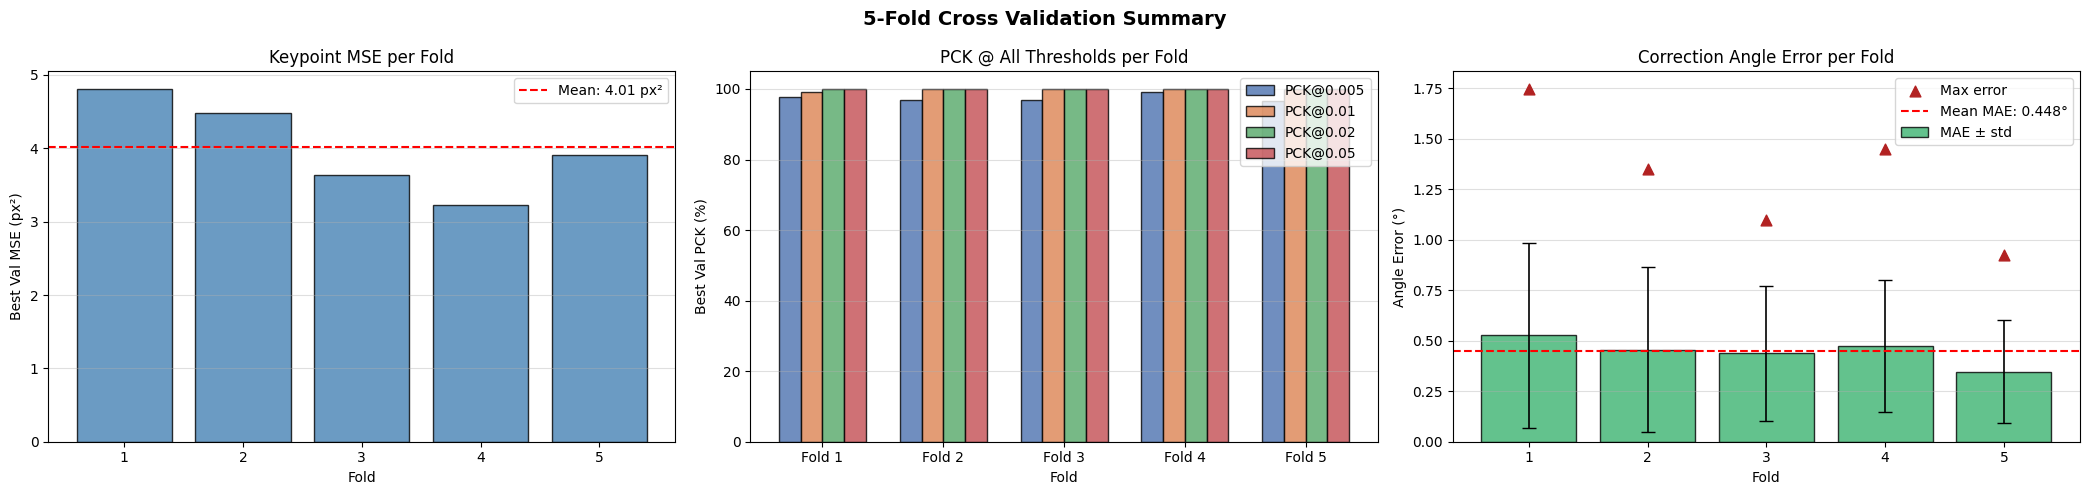


5-FOLD CROSS VALIDATION SUMMARY
Keypoint MSE (px²):  4.01  ±  0.57
PCK@0.005:            97.5%  ±  0.9%
PCK@0.01:            99.8%  ±  0.3%
PCK@0.02:            100.0%  ±  0.0%
PCK@0.05:            100.0%  ±  0.0%
Angle MAE (°):      0.448  ±  0.058
Angle Std (°):      0.356  ±  0.070
Angle Max (°):      1.314  ±  0.284


In [12]:
if os.path.exists(COCO_JSON_PATH):
    fold_results = run_kfold_cv(COCO_JSON_PATH, n_splits=5, epochs=KP_EPOCHS)
    plot_kfold_summary(fold_results)
else:
    print("Annotation file not found — 5-fold CV skipped.")

### Pooled cross-validation agreement (n ≈ 107)

Pools the per-hemisphere `(gt, pred)` correction angles across the five folds (returned by
`evaluate_fold_angles`) and reports the full agreement battery — the cross-validation
column of the summary table.

In [13]:
# ── Pooled 5-fold CV correction-angle agreement ──
# Uses the per-case (gt, pred) pairs now returned by evaluate_fold_angles,
# pooled across the five folds (n ~= 107).
if 'fold_results' in locals() and fold_results and all(
        r.get("angle_stats") and "gt" in r["angle_stats"] for r in fold_results):
    cv_gt   = np.array([a for r in fold_results for a in r["angle_stats"]["gt"]])
    cv_pred = np.array([a for r in fold_results for a in r["angle_stats"]["pred"]])
    cv_stats = angle_agreement_report(cv_gt, cv_pred, label="5-fold CV (pooled across folds)")

    try:  # persist per-case pairs (guarded for read-only dirs)
        rows = [{"fold": r["fold"], "gt_angle": g, "pred_angle": p}
                for r in fold_results
                for g, p in zip(r["angle_stats"]["gt"], r["angle_stats"]["pred"])]
        pd.DataFrame(rows).to_csv("angle_pairs_cv.csv", index=False)
        print("Wrote angle_pairs_cv.csv")
    except Exception as e:
        print(f"(CV pairs CSV not written: {e})")
else:
    print("Run the 5-fold CV cell first (need per-fold gt/pred angle pairs).")


  5-fold CV (pooled across folds)   (n = 107 limb hemispheres)
Absolute correction-angle error (degrees)
  mean    : 0.4499
  median  : 0.3265
  std     : 0.3706
  min     : 0.0093
  max     : 1.7463
  RMSE    : 0.5818
  within +/-1.63 deg : 99.1%

Agreement
  ICC(2,1) : 0.992 (0.990-0.990 95% CI), p = 4.5e-96   [pingouin ICC(2,1)]
  Pearson r: 0.9918

Bland-Altman (predicted - GT)
  bias (mean diff)       : -0.0513
  95% limits of agreement: [-1.1925, +1.0899]

Wrote angle_pairs_cv.csv


## Final Training Run

With cross validation complete, train the model on the fixed 80 / 10 / 10 split
and save the best checkpoint (lowest validation MSE).

In [14]:
if 'train_loader' in locals():
    model_global.train()
    _ = model_global(next(iter(train_loader))["image"].to(device))

    train_losses, val_losses, val_mses, val_pcks_all = train_global_routine(
        model_global, train_loader, val_loader,
        optimizer_global, scheduler_global, KP_EPOCHS, device,
    )
    model_global.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True))
    print(f"Best checkpoint loaded from '{CHECKPOINT_PATH}'.")
else:
    print("Data loaders not initialised — training skipped.")

Epoch 0001/750 | Train:  0.061551 | Val:  0.004039 | MSE:  140711.27 px² | PCK@0.005:   0.0% | PCK@0.010:   0.0% | PCK@0.020:   0.0% | PCK@0.050:   1.7%
Epoch 0002/750 | Train:  0.004272 | Val:  0.003911 | MSE:  145466.41 px² | PCK@0.005:   0.0% | PCK@0.010:   0.0% | PCK@0.020:   0.0% | PCK@0.050:   0.0%
Epoch 0003/750 | Train:  0.001924 | Val:  0.001160 | MSE:  142828.73 px² | PCK@0.005:   0.0% | PCK@0.010:   0.0% | PCK@0.020:   0.0% | PCK@0.050:   0.0%
Epoch 0004/750 | Train:  0.001335 | Val:  0.001025 | MSE:  145622.53 px² | PCK@0.005:   0.0% | PCK@0.010:   0.0% | PCK@0.020:   0.0% | PCK@0.050:   0.0%
Epoch 0005/750 | Train:  0.001191 | Val:  0.000989 | MSE:  136758.98 px² | PCK@0.005:   0.0% | PCK@0.010:   0.0% | PCK@0.020:   0.0% | PCK@0.050:   0.0%
Epoch 0006/750 | Train:  0.001121 | Val:  0.001143 | MSE:  130488.41 px² | PCK@0.005:   0.0% | PCK@0.010:   0.0% | PCK@0.020:   0.0% | PCK@0.050:   0.0%
Epoch 0007/750 | Train:  0.001057 | Val:  0.000915 | MSE:  134519.41 px² | PCK@0.0

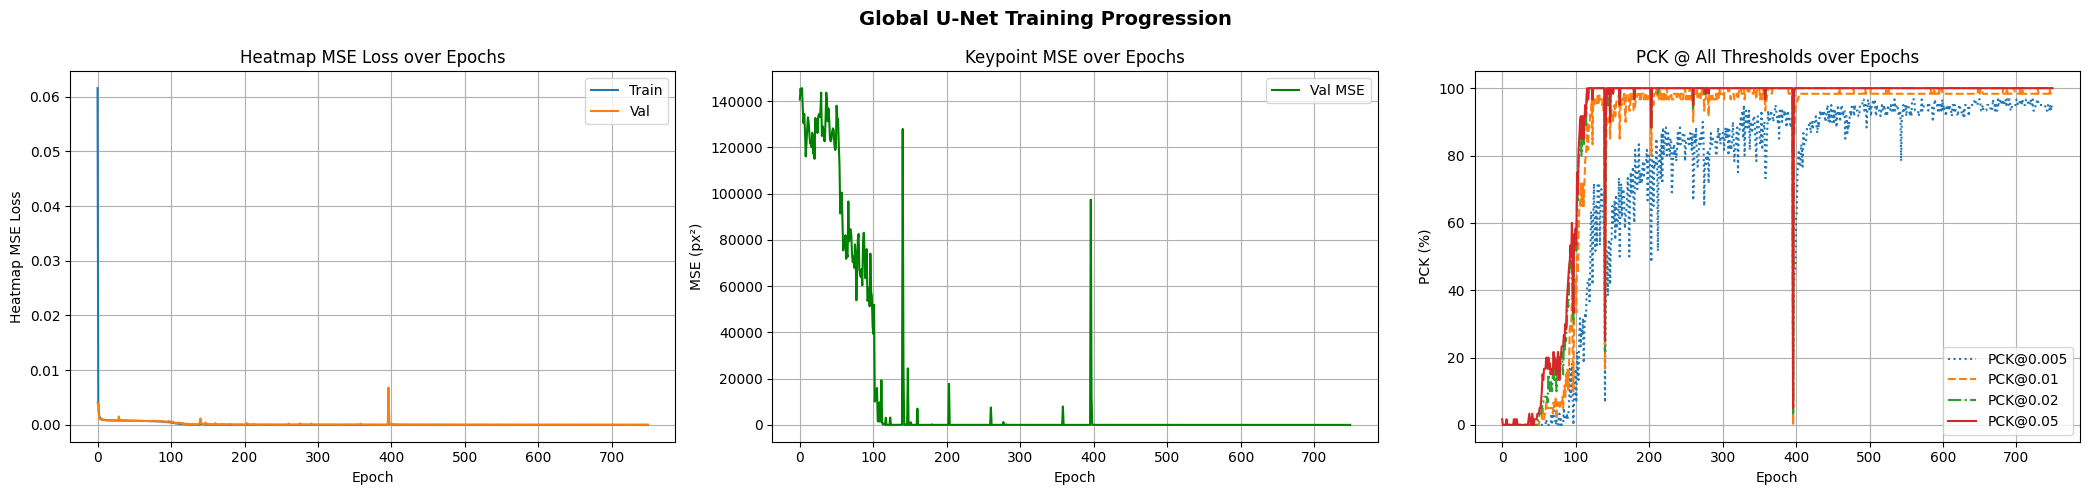

In [15]:
if 'train_losses' in locals():
    pck_005 = [v[0.005]*100 for v in val_pcks_all]
    pck_01  = [v[0.01] *100 for v in val_pcks_all]
    pck_02  = [v[0.02] *100 for v in val_pcks_all]
    pck_05  = [v[0.05] *100 for v in val_pcks_all]

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))

    axes[0].plot(train_losses, label="Train"); axes[0].plot(val_losses, label="Val")
    axes[0].set_title("Heatmap MSE Loss over Epochs")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Heatmap MSE Loss")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(val_mses, color="green", label="Val MSE")
    axes[1].set_title("Keypoint MSE over Epochs")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE (px²)")
    axes[1].legend(); axes[1].grid(True)

    axes[2].plot(pck_005, linestyle=":",  label="PCK@0.005")
    axes[2].plot(pck_01,  linestyle="--", label="PCK@0.01")
    axes[2].plot(pck_02,  linestyle="-.", label="PCK@0.02")
    axes[2].plot(pck_05,  linestyle="-",  label="PCK@0.05")
    axes[2].set_title("PCK @ All Thresholds over Epochs")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("PCK (%)")
    axes[2].legend(); axes[2].grid(True)

    plt.suptitle("Global U-Net Training Progression", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("Training results not found -- plotting skipped.")

## Test-Set Correction Angle Evaluation

The final trained model evaluates the held-out 10 % test set.  For each image
hemisphere the full Miniaci geometry pipeline runs: Fujisawa point, target ankle
intersection, and correction angle Alpha.  Results are reported as angular error
statistics and visualised with GT / prediction overlay diagrams.

In [16]:
if 'test_loader' in locals():
    model_global.eval()
    global_results = []

    with torch.no_grad():
        for batch in test_loader:
            imgs         = batch["image"].to(device)
            pred_hms     = model_global(imgs)
            coords_batch = extract_coordinates(pred_hms.cpu(), scale_factor=1.0/HEATMAP_SCALE).numpy()
            gts_batch    = batch["keypoint"].numpy()
            paths_batch  = batch["img_path"]
            orig_sizes   = batch["orig_size"].numpy()

            for b in range(len(imgs)):
                orig_shape = orig_sizes[b]
                pred_c, gt_c, path_b = coords_batch[b], gts_batch[b], paths_batch[b]

                res_l = res_r = None
                for base, hemi_key in [(0, "res_l"), (6, "res_r")]:
                    pts_gt, pts_pred = {}, {}
                    for k_off, name in enumerate(_SIDE_KEYS):
                        slot = base + k_off
                        if gt_c[slot][0] >= 0:
                            pts_gt[name]   = map_global_to_orig(gt_c[slot],   orig_shape, TARGET_SIZE)
                            pts_pred[name] = map_global_to_orig(pred_c[slot], orig_shape, TARGET_SIZE)

                    if all(k in pts_gt for k in _SIDE_KEYS) and all(k in pts_pred for k in _SIDE_KEYS):
                        gt_alpha,   gt_fuji,  gt_ank,  gt_targ  = evaluate_side_geometry(pts_gt)
                        pred_alpha, p_fuji,   p_ank,   p_targ   = evaluate_side_geometry(pts_pred)
                        pts_gt.update(fujisawa=gt_fuji,  ankle_c=gt_ank,  target_at_ankle=gt_targ)
                        pts_pred.update(fujisawa=p_fuji, ankle_c=p_ank,   target_at_ankle=p_targ)
                        result = {"side": ("Left" if base==0 else "Right") + " Image Hemisphere",
                                  "gt_angle": gt_alpha, "pred_angle": pred_alpha,
                                  "gt_pts": pts_gt,     "pred_pts": pts_pred}
                        if hemi_key == "res_l": res_l = result
                        else:                   res_r = result

                if res_l or res_r:
                    global_results.append({"img_path": path_b,
                                           "filename": os.path.basename(path_b),
                                           "res_l": res_l, "res_r": res_r})

    print(f"Inference complete: {len(global_results)} radiographs processed.")
else:
    print("Test loader not initialised — inference skipped.")

Inference complete: 6 radiographs processed.



TEST-SET PERFORMANCE SUMMARY
Evaluated hemisphere cases: 12 (6 left, 6 right)
Mean absolute error (all):        0.4627°
Mean absolute error (left hemi):  0.5248°
Mean absolute error (right hemi): 0.4006°
Std dev of abs errors (all):      0.4530°
Max absolute error    (all):      1.7641°


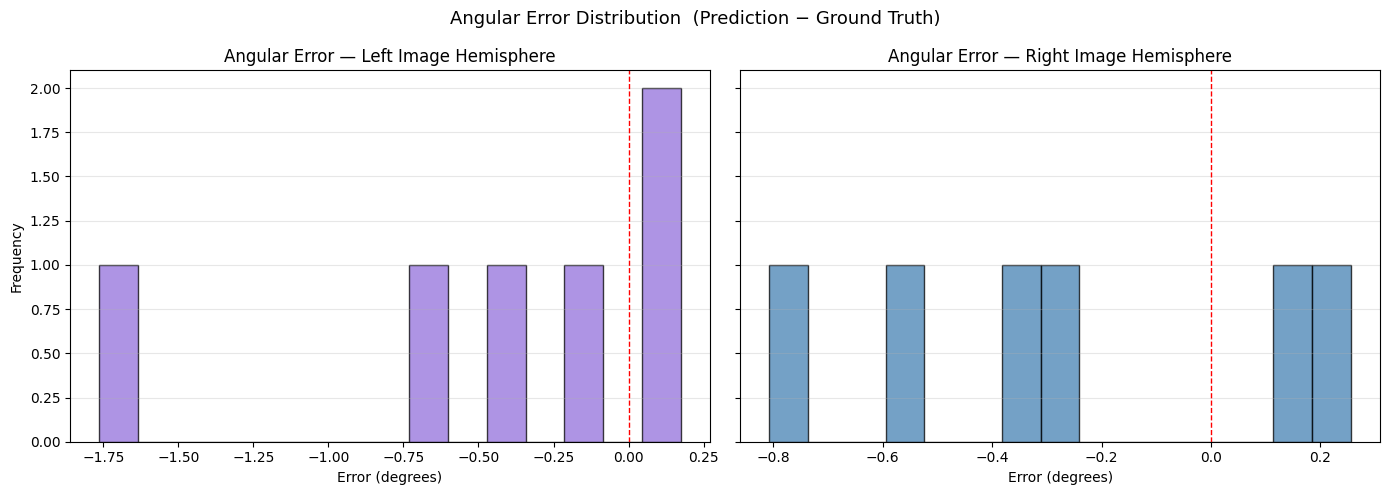

In [17]:
if 'global_results' in locals() and global_results:
    all_errors_lh, all_errors_rh = [], []
    for item in global_results:
        if item["res_l"]: all_errors_lh.append(item["res_l"]["pred_angle"] - item["res_l"]["gt_angle"])
        if item["res_r"]: all_errors_rh.append(item["res_r"]["pred_angle"] - item["res_r"]["gt_angle"])
    all_errors = all_errors_lh + all_errors_rh

    if all_errors:
        abs_all = [abs(e) for e in all_errors]

        print("\n" + "="*55)
        print("TEST-SET PERFORMANCE SUMMARY")
        print("="*55)
        print(f"Evaluated hemisphere cases: {len(all_errors)} "
              f"({len(all_errors_lh)} left, {len(all_errors_rh)} right)")
        print(f"Mean absolute error (all):        {np.mean(abs_all):.4f}\u00b0")
        if all_errors_lh:
            print(f"Mean absolute error (left hemi):  {np.mean([abs(e) for e in all_errors_lh]):.4f}\u00b0")
        if all_errors_rh:
            print(f"Mean absolute error (right hemi): {np.mean([abs(e) for e in all_errors_rh]):.4f}\u00b0")
        print(f"Std dev of abs errors (all):      {np.std(abs_all):.4f}\u00b0")
        print(f"Max absolute error    (all):      {np.max(abs_all):.4f}\u00b0")
        print("="*55)

        fig, (ax_lh, ax_rh) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
        for ax, errors, label, color in [
            (ax_lh, all_errors_lh, "Left Image Hemisphere",  "mediumpurple"),
            (ax_rh, all_errors_rh, "Right Image Hemisphere", "steelblue"),
        ]:
            if errors:
                ax.hist(errors, bins=15, color=color, edgecolor="black", alpha=0.75)
                ax.axvline(0, color="red", linestyle="dashed", linewidth=1)
                ax.set_title(f"Angular Error — {label}")
                ax.set_xlabel("Error (degrees)"); ax.grid(True, axis="y", alpha=0.3)
            else:
                ax.set_visible(False)
        ax_lh.set_ylabel("Frequency")
        fig.suptitle("Angular Error Distribution  (Prediction − Ground Truth)", fontsize=13)
        plt.tight_layout(); plt.show()
else:
    print("No inference results found — evaluation skipped.")

### Held-out test agreement (n = 12) and combined summary table

Same agreement battery on the fixed 80/10/10 hold-out test split, pooled from
`global_results`, followed by a combined cross-validation-vs-test summary table.

In [18]:
# ── Held-out test correction-angle agreement + combined summary table ──
# Pools the per-hemisphere (gt, pred) angles already collected in global_results.
if 'global_results' in locals() and global_results:
    _tg, _tp = [], []
    for item in global_results:
        for hemi in ("res_l", "res_r"):
            if item.get(hemi):
                _tg.append(item[hemi]["gt_angle"])
                _tp.append(item[hemi]["pred_angle"])
    if _tg:
        test_gt, test_pred = np.array(_tg), np.array(_tp)
        test_stats = angle_agreement_report(test_gt, test_pred, label="Held-out test split")
        try:
            pd.DataFrame({"gt_angle": test_gt, "pred_angle": test_pred}).to_csv(
                "angle_pairs_test.csv", index=False)
            print("Wrote angle_pairs_test.csv")
        except Exception as e:
            print(f"(test pairs CSV not written: {e})")
    else:
        print("No valid test hemispheres found.")
else:
    print("Run the test-set inference cell first (need global_results).")

# ── Combined summary table (correction-angle agreement): 5-fold CV vs held-out test ──
if 'cv_stats' in locals() and 'test_stats' in locals():
    def _row(name, key, fmt="{:.2f}"):
        print(f"{name:<26}{fmt.format(cv_stats[key]):>12}{fmt.format(test_stats[key]):>12}")
    print("\n" + "=" * 50)
    print(f"{'Metric':<26}{'5-fold CV':>12}{'Test':>12}")
    print(f"{'':<26}{'n='+str(cv_stats['n']):>12}{'n='+str(test_stats['n']):>12}")
    print("=" * 50)
    _row("Mean abs error (deg)",   "mean")
    _row("Median abs error (deg)", "median")
    _row("SD abs error (deg)",     "std")
    _row("Max abs error (deg)",    "max")
    _row("RMSE (deg)",             "rmse")
    _row("ICC(2,1)",               "icc", "{:.3f}")
    _cvci = f"({cv_stats['icc_lo']:.2f}-{cv_stats['icc_hi']:.2f})" if not np.isnan(cv_stats['icc_lo']) else "n/a"
    _teci = f"({test_stats['icc_lo']:.2f}-{test_stats['icc_hi']:.2f})" if not np.isnan(test_stats['icc_lo']) else "n/a"
    print(f"{'  ICC 95% CI':<26}{_cvci:>12}{_teci:>12}")
    _cvp = f"{cv_stats['icc_pval']:.1e}"   if not np.isnan(cv_stats['icc_pval'])   else "n/a"
    _tep = f"{test_stats['icc_pval']:.1e}" if not np.isnan(test_stats['icc_pval']) else "n/a"
    print(f"{'  ICC p-value':<26}{_cvp:>12}{_tep:>12}")
    _row("Pearson r",              "pearson", "{:.3f}")
    _row("Within +/-1.63 deg (%)", "within_tol_pct", "{:.1f}")
    print("=" * 50)
else:
    print("\n(Combined summary table needs both cv_stats and test_stats.)")


  Held-out test split   (n = 12 limb hemispheres)
Absolute correction-angle error (degrees)
  mean    : 0.4627
  median  : 0.3217
  std     : 0.4731
  min     : 0.0661
  max     : 1.7641
  RMSE    : 0.6475
  within +/-1.63 deg : 91.7%

Agreement
  ICC(2,1) : 0.986 (0.940-1.000 95% CI), p = 7.9e-11   [pingouin ICC(2,1)]
  Pearson r: 0.9912

Bland-Altman (predicted - GT)
  bias (mean diff)       : -0.3605
  95% limits of agreement: [-1.4616, +0.7406]

Wrote angle_pairs_test.csv

Metric                       5-fold CV        Test
                                 n=107        n=12
Mean abs error (deg)              0.45        0.46
Median abs error (deg)            0.33        0.32
SD abs error (deg)                0.37        0.47
Max abs error (deg)               1.75        1.76
RMSE (deg)                        0.58        0.65
ICC(2,1)                         0.992       0.986
  ICC 95% CI               (0.99-0.99) (0.94-1.00)
  ICC p-value                  4.5e-96     7.9e-11
Pearson 

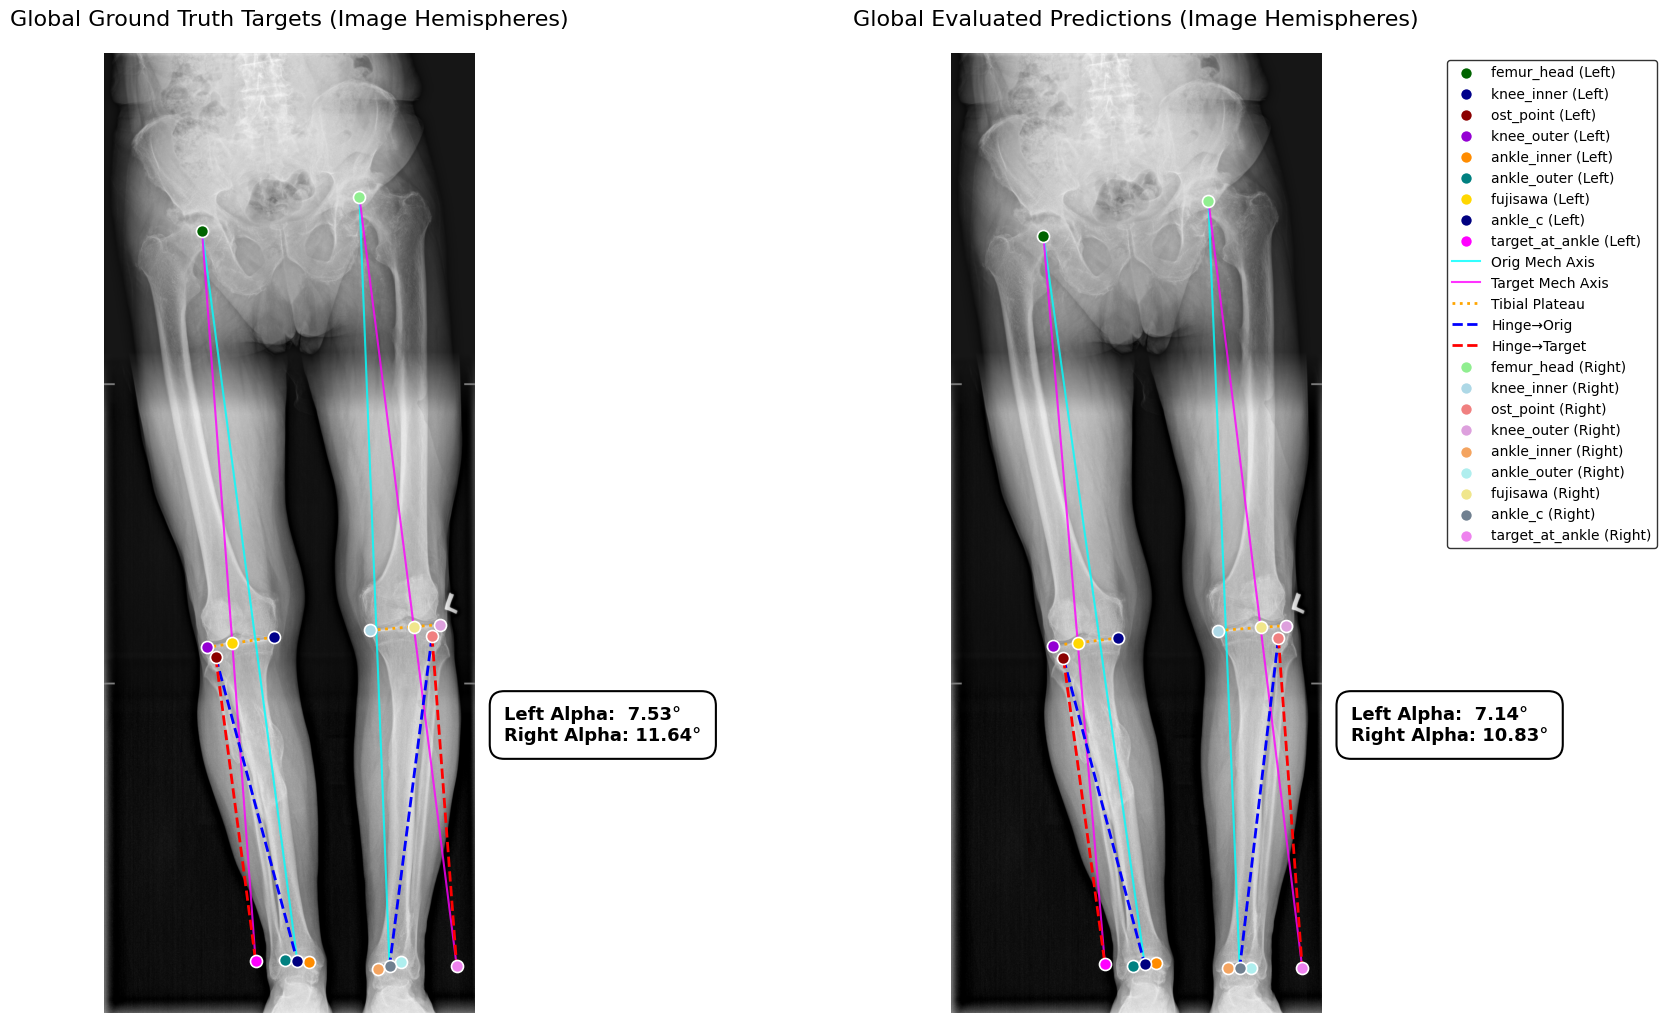

Overlay rendered for: 20_0.png


In [19]:
if 'global_results' in locals() and global_results:
    candidates   = [s for s in global_results if s["res_l"] and s["res_r"]]
    sample_entry = random.choice(candidates) if candidates else random.choice(global_results)
    img_target   = Image.open(sample_entry["img_path"]).convert("RGB")

    fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(22, 12))

    def draw_overlay(ax, data_item, is_gt=True):
        key   = "gt_angle" if is_gt else "pred_angle"
        title = ("Global Ground Truth Targets" if is_gt else "Global Evaluated Predictions")
        ax.imshow(img_target, cmap="gray")
        ax.set_title(title + " (Image Hemispheres)", fontsize=16, pad=20)

        lines = []
        if data_item.get("res_l"): lines.append(f"Left Alpha:  {data_item['res_l'][key]:.2f}\u00b0")
        if data_item.get("res_r"): lines.append(f"Right Alpha: {data_item['res_r'][key]:.2f}\u00b0")
        if lines:
            ax.text(1.08, 0.3, "\n".join(lines), transform=ax.transAxes,
                    ha="left", va="center", fontsize=13, weight="bold", color="black",
                    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.8", linewidth=1.5))

        for s_tag in ["res_l", "res_r"]:
            sd = data_item[s_tag]
            if not sd: continue
            pts    = sd["gt_pts"] if is_gt else sd["pred_pts"]
            suffix = "_lh" if s_tag == "res_l" else "_rh"
            side   = "Left" if s_tag == "res_l" else "Right"

            for k_name, coord in pts.items():
                if isinstance(coord, np.ndarray) and coord.shape == (2,):
                    ax.scatter(coord[0], coord[1], s=75,
                               color=LANDMARK_COLORS.get(f"{k_name}{suffix}", "magenta"),
                               edgecolors="white", linewidths=1.2, zorder=5,
                               label=f"{k_name} ({side})")

            ax.plot([pts["femur_head"][0], pts["ankle_c"][0]],
                    [pts["femur_head"][1], pts["ankle_c"][1]],
                    color="cyan",    linestyle="-",  linewidth=1.5, alpha=0.8, zorder=2, label="Orig Mech Axis")
            ax.plot([pts["femur_head"][0], pts["target_at_ankle"][0]],
                    [pts["femur_head"][1], pts["target_at_ankle"][1]],
                    color="magenta", linestyle="-",  linewidth=1.5, alpha=0.8, zorder=3, label="Target Mech Axis")
            ax.plot([pts["knee_inner"][0], pts["knee_outer"][0]],
                    [pts["knee_inner"][1], pts["knee_outer"][1]],
                    color="orange",  linestyle=":",  linewidth=2,              zorder=4, label="Tibial Plateau")
            ax.plot([pts["ost_point"][0], pts["ankle_c"][0]],
                    [pts["ost_point"][1], pts["ankle_c"][1]],
                    color="blue",    linestyle="--", linewidth=2,              zorder=4, label="Hinge→Orig")
            ax.plot([pts["ost_point"][0], pts["target_at_ankle"][0]],
                    [pts["ost_point"][1], pts["target_at_ankle"][1]],
                    color="red",     linestyle="--", linewidth=2,              zorder=4, label="Hinge→Target")

        ax.axis("off")
        if not is_gt:
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            if by_label:
                ax.legend(by_label.values(), by_label.keys(),
                          bbox_to_anchor=(1.32, 1.0), loc="upper left",
                          fontsize=10, frameon=True, facecolor="white", edgecolor="black")

    draw_overlay(ax_gt,   sample_entry, is_gt=True)
    draw_overlay(ax_pred, sample_entry, is_gt=False)
    plt.subplots_adjust(left=0.05, bottom=0.1, top=0.9, wspace=0.35, right=0.72)
    plt.show()
    print(f"Overlay rendered for: {sample_entry['filename']}")
else:
    print("No inference results found — visualisation skipped.")